# basic statistics

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List
from anndata import AnnData

from tic.data import load_bgi_dataset, load_xenium_dataset
from tic.constant import EPITHELIAL_GENES, MESENCHYMAL_GENES, EMT_TF

In [8]:
BGI_DATA_DIR = "/Users/zhangjiahao/Dataset/BGI"

bgi_datasets   = ["C03628C1", "B03425E1", "B03425E3"]
xenium_datasets = ["xenium_ffpe_human_breast",
                   "xenium_kidney_cancer",
                   "xenium_pancreas_cancer"]

# EMT gene panel
EMT_GENES = list(EPITHELIAL_GENES) + list(MESENCHYMAL_GENES) + list(EMT_TF)

In [9]:
def gene_stats(
    adata: AnnData,
    genes: List[str],
) -> pd.DataFrame:
    """
    Basic stats (mean, std, #non-zero cells, fraction non-zero) for `genes`.
    Keeps original scale (no log/normalisation assumed).

    Returns
    -------
    DataFrame indexed by gene with columns
    [mean, std, nonzero_cells, nonzero_fraction]
    """
    # restrict to genes that exist in this dataset
    present = [g for g in genes if g in adata.var_names]
    if not present:
        raise ValueError("None of the requested genes found in adata.")
        
    X = adata[:, present].X
    if not isinstance(X, np.ndarray):  # sparse → dense
        X = X.toarray()

    mean  = X.mean(axis=0)
    std   = X.std(axis=0)
    nz    = (X > 0).sum(axis=0)
    frac  = nz / X.shape[0]

    return pd.DataFrame({
        "mean"            : mean,
        "std"             : std,
        "nonzero_cells"   : nz,
        "nonzero_fraction": frac
    }, index=present)

In [10]:
def load_all_stats(
    bgi_ids: List[str],
    xenium_ids: List[str],
    bgi_root: str,
    genes: List[str],
) -> pd.DataFrame:
    """
    Returns a tidy DataFrame with a multi-index:
        index   = (platform, sample, gene)
        columns = mean, std, nonzero_cells, nonzero_fraction
    """
    records = []

    # BGI
    for sid in bgi_ids:
        ad = load_bgi_dataset(sid, data_dir=bgi_root, normalize=None, log=False)
        df = gene_stats(ad, genes)
        df["sample"]   = sid
        df["platform"] = "BGI"
        records.append(df.reset_index())

    # Xenium
    for sid in xenium_ids:
        ad = load_xenium_dataset(sid, normalize=None, log=False)
        df = gene_stats(ad, genes)
        df["sample"]   = sid
        df["platform"] = "Xenium"
        records.append(df.reset_index())

    tidy = pd.concat(records, ignore_index=True)\
             .rename(columns={"index": "gene"})\
             .set_index(["platform", "sample", "gene"])
    return tidy

In [12]:
def barplot_fraction(stats: pd.DataFrame, figsize=(12, 4)):
    # average across samples inside each platform
    frac = (stats["nonzero_fraction"]
            .groupby(["platform", "gene"])
            .mean()
            .unstack("platform"))
    
    frac.plot(kind="bar",
              figsize=figsize,
              width=0.85,
              alpha=0.9)
    plt.ylabel("Fraction of cells (mean across samples)")
    plt.title("Cellular prevalence of EMT genes\nBGI vs Xenium")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()

In [13]:
def scatter_mean_vs_frac(stats: pd.DataFrame):
    plt.figure(figsize=(6, 5))
    for platform, grp in stats.groupby(level="platform"):
        plt.scatter(grp["nonzero_fraction"],
                    grp["mean"],
                    label=platform,
                    alpha=0.8,
                    s=40)
    # annotate genes once (using the first platform’s values)
    ann = stats.loc["BGI"].reset_index() if "BGI" in stats.index.levels[0] \
          else stats.iloc[:len(EMT_GENES)].reset_index()
    for _, r in ann.iterrows():
        plt.text(r["nonzero_fraction"], r["mean"], r["gene"],
                 fontsize=7, alpha=0.6)
    plt.xlabel("Fraction of expressing cells")
    plt.ylabel("Mean expression")
    plt.title("EMT gene usage: BGI vs Xenium")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()

In [14]:
stats = load_all_stats(bgi_datasets, xenium_datasets, BGI_DATA_DIR, EMT_GENES)

2025-06-16 10:53:03,336 INFO Loaded cached cell types from /Users/zhangjiahao/Dataset/BGI/C03628C1/C03628C1_tissue_llm_cell_types.parquet
2025-06-16 10:53:03,336 | INFO     | tic.data.bgi.loader | Loaded cached cell types from /Users/zhangjiahao/Dataset/BGI/C03628C1/C03628C1_tissue_llm_cell_types.parquet
2025-06-16 10:53:03,517 INFO Loaded BGI sample C03628C1 (tissue) – 8317 cells × 37513 genes
2025-06-16 10:53:03,517 | INFO     | tic.data.bgi.loader | Loaded BGI sample C03628C1 (tissue) – 8317 cells × 37513 genes
2025-06-16 10:53:03,679 INFO Loaded cached cell types from /Users/zhangjiahao/Dataset/BGI/B03425E1/B03425E1_tissue_llm_cell_types.parquet
2025-06-16 10:53:03,679 | INFO     | tic.data.bgi.loader | Loaded cached cell types from /Users/zhangjiahao/Dataset/BGI/B03425E1/B03425E1_tissue_llm_cell_types.parquet
2025-06-16 10:53:03,931 INFO Loaded BGI sample B03425E1 (tissue) – 12939 cells × 37388 genes
2025-06-16 10:53:03,931 | INFO     | tic.data.bgi.loader | Loaded BGI sample B034

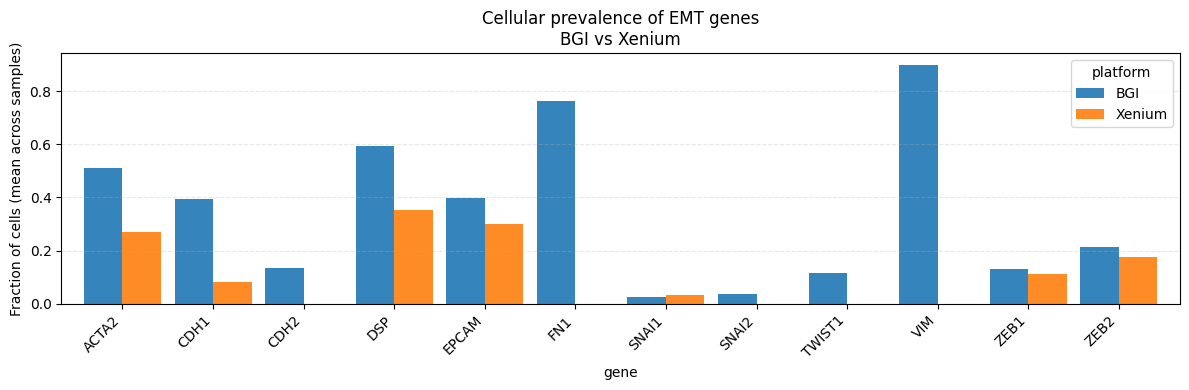

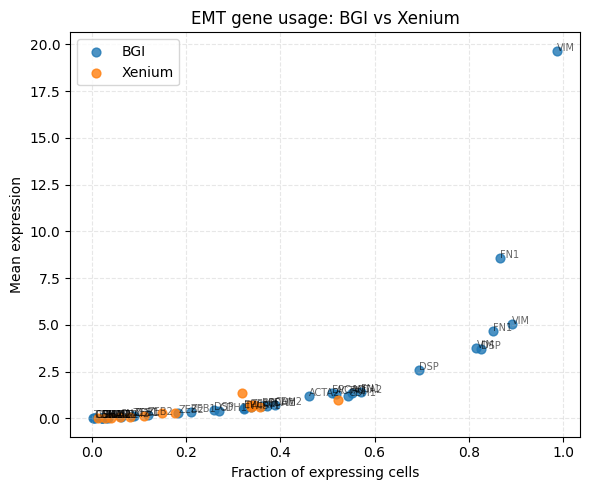

In [16]:
barplot_fraction(stats)
scatter_mean_vs_frac(stats)